In [21]:
import pandas as pd
import numpy as np
# this results is from 417 galaxies base samples
results = pd.read_csv('/data/zsl23/basemodels/out/results.txt', sep="\s+", header = 0)

In [22]:
results_sorted = results.sort_values(by='best.reduced_chi_square')
results_sorted[['id', 'best.reduced_chi_square']].head()

,id,best.reduced_chi_square
362,UGC08246,0.095846
311,IC3611,0.125268
385,NGC5348,0.169685
274,NGC4437,0.177431
269,NGC4503,0.217743


In [23]:
list(results)

['id',
 'bayes.attenuation.E_BV_factor',
 'bayes.attenuation.E_BV_factor_err',
 'bayes.attenuation.E_BV_lines',
 'bayes.attenuation.E_BV_lines_err',
 'bayes.attenuation.E_BVs',
 'bayes.attenuation.E_BVs_err',
 'bayes.attenuation.galex.FUV',
 'bayes.attenuation.galex.FUV_err',
 'bayes.attenuation.generic.bessell.B',
 'bayes.attenuation.generic.bessell.B_err',
 'bayes.attenuation.generic.bessell.V',
 'bayes.attenuation.generic.bessell.V_err',
 'bayes.attenuation.powerlaw_slope',
 'bayes.attenuation.powerlaw_slope_err',
 'bayes.attenuation.uv_bump_amplitude',
 'bayes.attenuation.uv_bump_amplitude_err',
 'bayes.attenuation.uv_bump_wavelength',
 'bayes.attenuation.uv_bump_wavelength_err',
 'bayes.attenuation.uv_bump_width',
 'bayes.attenuation.uv_bump_width_err',
 'bayes.dust.alpha',
 'bayes.dust.alpha_err',
 'bayes.dust.gamma',
 'bayes.dust.gamma_err',
 'bayes.dust.qhac',
 'bayes.dust.qhac_err',
 'bayes.dust.umin',
 'bayes.dust.umin_err',
 'bayes.nebular.f_dust',
 'bayes.nebular.f_dust_err

In [24]:
properties = results[['id','bayes.stellar.m_star','bayes.stellar.m_star_err','bayes.sfh.sfr','bayes.sfh.sfr_err',
                      'bayes.dust.mass','bayes.dust.mass_err','bayes.attenuation.generic.bessell.V', 
                      'bayes.attenuation.generic.bessell.V_err','bayes.stellar.age_m_star','bayes.stellar.age_m_star_err']] 
rename_map = {
    "name": "#id",
    "bayes.stellar.m_star": "Galaxy Mass (solMass)", "bayes.stellar.m_star_err": "Galaxy Mass Error (solMass)",
    "bayes.sfh.sfr": "Star Formation Rate (solMass yr-1)", "bayes.sfh.sfr_err": "Star Formation Rate Error (solMass yr-1)",
    "bayes.dust.mass": "Total Dust Mass (solMass)", "bayes.dust.mass_err": "Total Dust Mass Error (solMass)",
    "bayes.attenuation.generic.bessell.V": "Av (mag)", "bayes.attenuation.generic.bessell.V_err": "Av Error (mag)",
    "bayes.stellar.age_m_star": "Average Galaxy Age (Myr)", "bayes.stellar.age_m_star_err": "Average Galaxy Age Error (Myr)",
}

properties = properties.rename(columns=rename_map)


In [25]:
# convert dust mass units from kg to Msol
properties[['Total Dust Mass (solMass)', 'Total Dust Mass Error (solMass)']] = properties[['Total Dust Mass (solMass)', 'Total Dust Mass Error (solMass)']] / 1.989e+30
properties.to_csv('baseproperties.csv', index=False)

In [26]:
# just a side quest to look into dust properties more clearly
dust_properties = results[['id','bayes.dust.luminosity','bayes.dust.luminosity_err','bayes.dust.mass','bayes.dust.mass_err', 'bayes.dust.alpha',
 'bayes.dust.alpha_err','bayes.dust.gamma','bayes.dust.gamma_err','bayes.dust.qhac','bayes.dust.qhac_err','bayes.dust.umin','bayes.dust.umin_err']]
dust_properties.to_csv('baseprop_dust.csv', index=False)

In [40]:
mask = np.column_stack([properties['id'].str.contains(r"NGC1189", na=False) for col in properties])
properties.loc[mask.any(axis=1)]


,id,Galaxy Mass (solMass),Galaxy Mass Error (solMass),Star Formation Rate (solMass yr-1),Star Formation Rate Error (solMass yr-1),Total Dust Mass (solMass),Total Dust Mass Error (solMass),Av (mag),Av Error (mag),Average Galaxy Age (Myr),Average Galaxy Age Error (Myr)
6,NGC1189,4.254524e+09,1.111238e+09,0.312184,0.049992,1.950631e+07,9.676227e+06,0.145272,0.048203,3324.920205,1439.534655


In [28]:
# read in the dustpedia fits properties
dustpedia = pd.read_csv('dustpedia_cigale_results_final_version.csv')

In [29]:
dustpedia = dustpedia[['id','Mstar__Msol','Mstar_err','SFR__Msol_per_yr','SFR_err','Mdust__Msol','Mdust_err','Av_b90','Av_b90_err']]
targets = ["NGC0584", "NGC0586", "NGC0678", "NGC0855", "PGC008962", "NGC0895", "NGC1189", "IC2233"]
ordered = dustpedia.set_index('id').loc[targets].reset_index() # set id as index column, locate the targets, then reset the id column
ordered

,id,Mstar__Msol,Mstar_err,SFR__Msol_per_yr,SFR_err,Mdust__Msol,Mdust_err,Av_b90,Av_b90_err
0,NGC0584,9.624000e+10,8.935000e+09,0.01214,0.008046,2988000.0,2328000.0,0.025,0.006
1,NGC0586,9.283000e+09,1.714000e+09,0.04242,0.028660,3084000.0,695600.0,0.260,0.033
2,NGC0678,6.572000e+10,8.371000e+09,0.09408,0.067070,10050000.0,1947000.0,0.206,0.027
3,NGC0855,9.148000e+08,2.132000e+08,0.02893,0.014410,208500.0,52660.0,0.233,0.046
4,PGC008962,5.263000e+08,2.366000e+08,0.09298,0.010520,233200.0,444400.0,0.022,0.016
5,NGC0895,1.947000e+10,3.651000e+09,2.96900,0.353600,49090000.0,2475000.0,0.194,0.042
6,NGC1189,4.074000e+09,1.490000e+09,0.36670,0.054380,9366000.0,3690000.0,0.156,0.045
7,IC2233,1.355000e+09,1.674000e+08,0.20940,0.016570,1006000.0,360900.0,0.048,0.015


In [30]:
from astropy.io import fits # to read in fits file
path = '/data/zsl23/basemodels/out/results.fits'
hdul = fits.open(path)
# hdul[0] is the primary HDU, hdul[1] is the first extension HDU
# A table will always be in an extension HDU, never in a primary HDU.
data = hdul[1].data
hdr = hdul[1].header


In [31]:
print(hdr) # this provides the units for the results parameters

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1959 / length of dimension 1                          NAXIS2  =                  417 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                  243 / number of table fields                         TTYPE1  = 'id      '                                                            TFORM1  = '23A     '                                                            TTYPE2  = 'bayes.attenuation.E_BV_factor'                                       TFORM2  = 'D       '                                                            TUNIT2  = ''                            

In [32]:
import matplotlib.pyplot as plt
# lets make a function for histogram comparison!!
def plothistogram(prop, dprop, prop_name, bins=50):
    #weights = 1 / err**2
    #mean = np.average(prop, weights=weights)
    #std = np.std(prop, axis=0)
    #n=len(prop)
    #sterr = std/np.sqrt(n)
    median = np.nanmedian(prop, axis=0)
    dmedian = np.nanmedian(dprop, axis=0)
    # we mainly want median only

    #plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2e}')
    #plt.axvspan(mean - sterr, mean + sterr, color='red', alpha=0.2, label='±1σ')
    plt.hist(prop, density=False, bins=bins, alpha=0.6, label='This sample', color='orange')
    plt.hist(dprop, density=False, bins=bins, alpha=0.4, label='DustPedia', color='blue')
    plt.axvline(median, color='darkorange', linestyle='--', label=f'Median = {median:.2e}')
    plt.axvline(dmedian, color='navy', linestyle='--', label=f'DustPedia Median = {dmedian:.2e}')
    
    plt.ylabel('Counts')
    plt.xlabel(prop_name)
    plt.legend()
    plt.show()

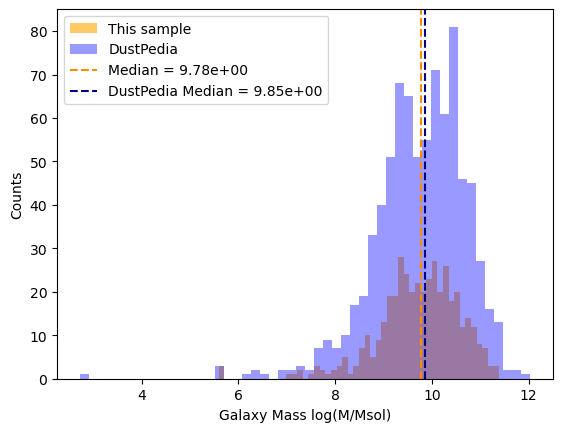

In [33]:
galmassprop = np.log10(properties['Galaxy Mass (solMass)'])
dgalmassprop = np.log10(dustpedia['Mstar__Msol'])
plothistogram(galmassprop, dgalmassprop, 'Galaxy Mass log(M/Msol)')

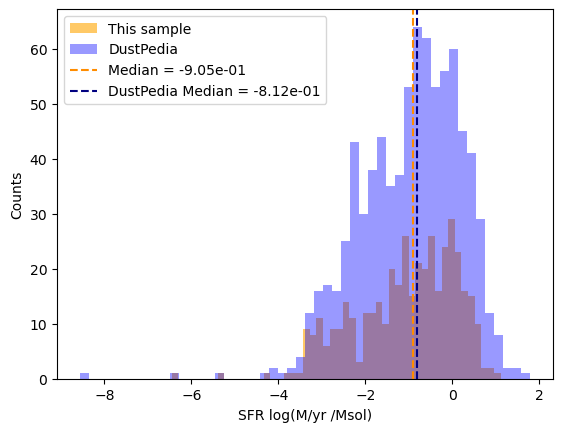

In [34]:
sfrprop = np.log10(properties['Star Formation Rate (solMass yr-1)'])
dsfrprop = np.log10(dustpedia['SFR__Msol_per_yr'])
plothistogram(sfrprop, dsfrprop, 'SFR log(M/yr /Msol)')

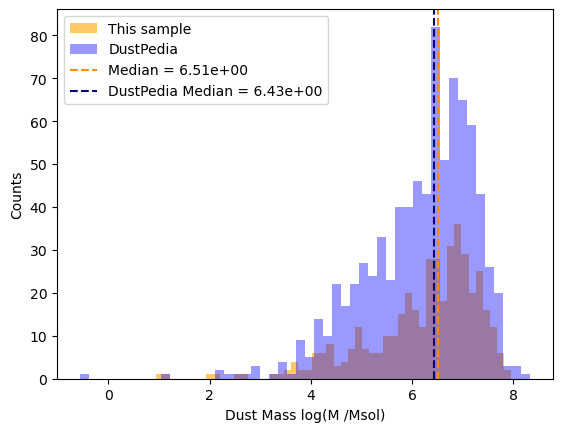

In [35]:
dustmassprop = np.log10(properties['Total Dust Mass (solMass)'])
ddustmassprop = np.log10(dustpedia['Mdust__Msol'])
plothistogram(dustmassprop, ddustmassprop, 'Dust Mass log(M /Msol)')

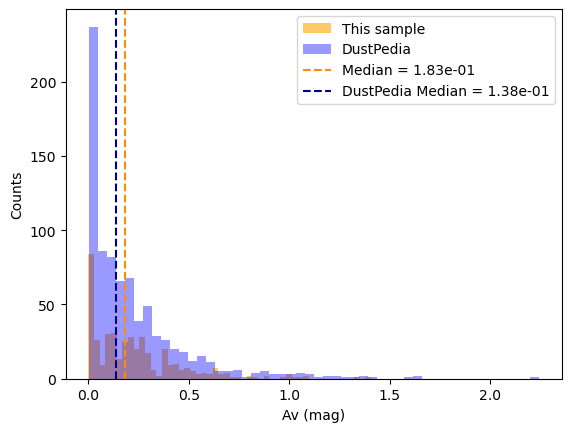

In [36]:
Avprop = properties['Av (mag)']
dAvprop = dustpedia['Av_b90']
plothistogram(Avprop, dAvprop, 'Av (mag)')

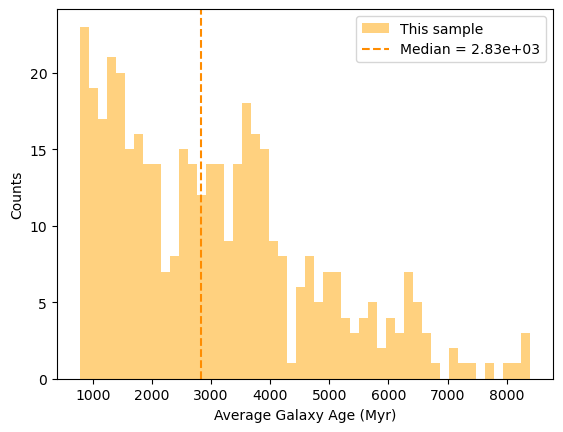

In [37]:
galageprop = properties['Average Galaxy Age (Myr)']
median = np.nanmedian(galageprop, axis=0)
    
plt.hist(galageprop, density=False, bins=50, alpha=0.5, label='This sample', color='orange')
 
plt.axvline(median, color='darkorange', linestyle='--', label=f'Median = {median:.2e}')

plt.ylabel('Counts')
plt.xlabel('Average Galaxy Age (Myr)')
plt.legend()
plt.show()

In [38]:
print(len(galageprop))

417
